## Aim 

In this code, the Land Surface Temperature data (LST) using the calculation of Ermeida et al. (2020) at the ward level are merged with the indices such as NDVI, NDBI, NNDWI and BSI. The script with the computation of the LST can be found [here](https://github.com/EllenB/lstroad/blob/main/notebooks/03_lst_bangalore_calc.ipynb) and the script for the indices [here](https://github.com/EllenB/lstroad/blob/main/notebooks/04_indices_bangalore.ipynb). 

In [1]:
from pathlib import Path

## import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import linregress, pearsonr
from sklearn.linear_model import LinearRegression

## Reading in the data

In [2]:
# Define the paths
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
IMAGES_DIR = BASE_DIR / "images"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


### Land Surface Temperature

In [3]:
lst_path = PROCESSED_DIR /'lstcalcsummer_bang.csv'
print(lst_path)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\lstcalcsummer_bang.csv


In [4]:
df_lst_mean_summer = pd.read_csv(lst_path)

In [5]:
df_lst_mean_summer.head()

,system:index,ward_name,mean,ward_id
0,0,25 - Vinayaka Layout,40.063313,25
1,1,2 - Aerocity,39.422320,2
2,2,3 - Chowdeshwari ward,39.380856,3
3,3,15 - Ramamurthy Nagara,39.406186,15
4,4,58 - Nagashettyhalli,38.373896,58


In [6]:
print(f"The minimum temperature is {df_lst_mean_summer['mean'].min()}.")
print(f"The maximum temperature is {df_lst_mean_summer['mean'].max()}.")

The minimum temperature is 36.44786789054648.
The maximum temperature is 43.20688102882611.


### Indices

In [7]:
indices_path = PROCESSED_DIR /'indices_wards_geemap_bang.csv'
df_indices = pd.read_csv(indices_path)

In [8]:
df_indices.head()

,system:index,Corporatio,ward_name,MNDWI,NDBI,BSI,NDVI,ward_id
0,0,West,25 - Vinayaka Layout,-0.337424,-0.022776,0.071129,0.297025,25
1,1,North,2 - Aerocity,-0.337253,-0.029647,0.068905,0.305434,2
2,2,North,3 - Chowdeshwari ward,-0.399920,-0.034285,0.058472,0.368122,3
3,3,East,15 - Ramamurthy Nagara,-0.274119,-0.026672,0.073142,0.249989,15
4,4,North,58 - Nagashettyhalli,-0.323029,-0.038849,0.057884,0.299915,58


In [9]:
merged = pd.merge(df_lst_mean_summer, df_indices, on='ward_name')
merged.head()

,system:index_x,ward_name,mean,ward_id_x,system:index_y,Corporatio,MNDWI,NDBI,BSI,NDVI,ward_id_y
0,0,25 - Vinayaka Layout,40.063313,25,0,West,-0.337424,-0.022776,0.071129,0.297025,25
1,1,2 - Aerocity,39.422320,2,1,North,-0.337253,-0.029647,0.068905,0.305434,2
2,2,3 - Chowdeshwari ward,39.380856,3,2,North,-0.399920,-0.034285,0.058472,0.368122,3
3,3,15 - Ramamurthy Nagara,39.406186,15,3,East,-0.274119,-0.026672,0.073142,0.249989,15
4,4,58 - Nagashettyhalli,38.373896,58,4,North,-0.323029,-0.038849,0.057884,0.299915,58


Only retain the relevant variables and rename:

In [10]:
merged = merged[['ward_name', 'mean', 'ward_id_x', 'Corporatio', 'MNDWI', 'NDBI', 'BSI', 'NDVI']]
merged.head()

,ward_name,mean,ward_id_x,Corporatio,MNDWI,NDBI,BSI,NDVI
0,25 - Vinayaka Layout,40.063313,25,West,-0.337424,-0.022776,0.071129,0.297025
1,2 - Aerocity,39.422320,2,North,-0.337253,-0.029647,0.068905,0.305434
2,3 - Chowdeshwari ward,39.380856,3,North,-0.399920,-0.034285,0.058472,0.368122
3,15 - Ramamurthy Nagara,39.406186,15,East,-0.274119,-0.026672,0.073142,0.249989
4,58 - Nagashettyhalli,38.373896,58,North,-0.323029,-0.038849,0.057884,0.299915


In [11]:
# Rename the columns
merged = merged.rename(columns={
    'ward_id_x': 'ward_id',
    'Corporatio_x': 'Corporation',
    'mean': 'mean_lst'
})
merged.head()

,ward_name,mean_lst,ward_id,Corporatio,MNDWI,NDBI,BSI,NDVI
0,25 - Vinayaka Layout,40.063313,25,West,-0.337424,-0.022776,0.071129,0.297025
1,2 - Aerocity,39.422320,2,North,-0.337253,-0.029647,0.068905,0.305434
2,3 - Chowdeshwari ward,39.380856,3,North,-0.399920,-0.034285,0.058472,0.368122
3,15 - Ramamurthy Nagara,39.406186,15,East,-0.274119,-0.026672,0.073142,0.249989
4,58 - Nagashettyhalli,38.373896,58,North,-0.323029,-0.038849,0.057884,0.299915


## Correlations

In [12]:
vars_df = merged[[
    "mean_lst",
    "NDVI",
    "NDBI",
    "BSI",
    "MNDWI"
]].dropna()

In [13]:
corr = vars_df.corr(method="pearson")

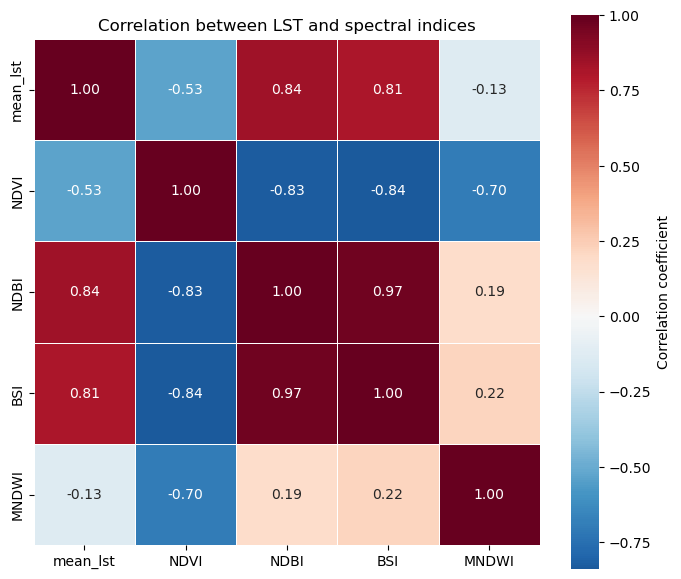

In [14]:
corr_path_indices = IMAGES_DIR / 'corr_indices_bangalore_computed.png'
plt.figure(figsize=(7, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation coefficient"}
)

plt.title("Correlation between LST and spectral indices")
plt.tight_layout()
plt.savefig(corr_path_indices, dpi=300, bbox_inches="tight")
plt.show()


#### NDVI

In [15]:
# x and y
x = merged[["NDVI"]]
Y = merged["mean_lst"]

In [16]:
fig_path = IMAGES_DIR / 'regression_bangalore_NDVI_computed.png'

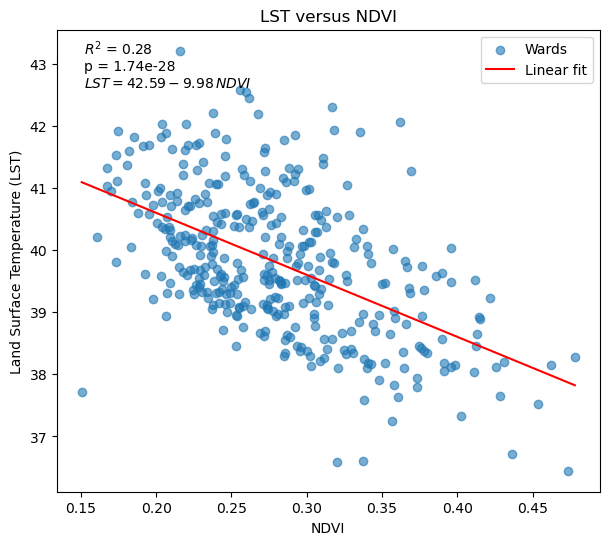

In [17]:
# x and y
x = merged["NDVI"]
y = merged["mean_lst"]

# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("NDVI")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus NDVI")
plt.legend()

# annotation
plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST = {intercept:.2f}{slope:.2f}\\,NDVI$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()


In [18]:
p_value

np.float64(1.7350523773193093e-28)

In [19]:
print(slope, intercept, r_value)

-9.984084993038083 42.5948920057178 -0.5331421615602332


In [20]:
pearsonr(merged['NDVI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.533142161560233), pvalue=np.float64(1.7350523773193064e-28))

In [21]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['NDVI']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.284
Model:                            OLS   Adj. R-squared:                  0.282
Method:                 Least Squares   F-statistic:                     145.7
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           1.74e-28
Time:                        22:59:30   Log-Likelihood:                -515.80
No. Observations:                 369   AIC:                             1036.
Df Residuals:                     367   BIC:                             1043.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         42.5949      0.237    179.728      0.0

In [22]:
pearsonr(merged['NDVI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.533142161560233), pvalue=np.float64(1.7350523773193064e-28))

#### MNDWI

In [23]:
# x and y
x = merged["MNDWI"]
y = merged["mean_lst"]

In [24]:
fig_path = IMAGES_DIR / 'regression_bangalore_MNDWI_computed.png'

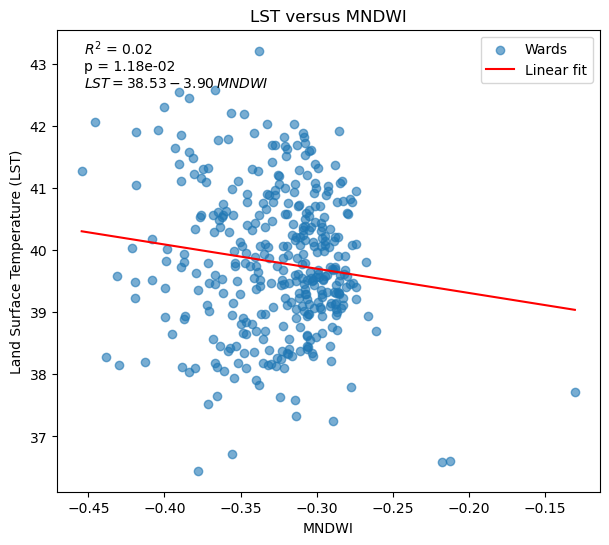

In [25]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("MNDWI")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus MNDWI")
plt.legend()

# annotation

plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST = {intercept:.2f}{slope:.2f}\\,MNDWI$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [26]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['MNDWI']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     6.411
Date:                Wed, 14 Jan 2026   Prob (F-statistic):             0.0118
Time:                        22:59:50   Log-Likelihood:                -574.30
No. Observations:                 369   AIC:                             1153.
Df Residuals:                     367   BIC:                             1160.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         38.5271      0.507     76.029      0.0

In [27]:
pearsonr(merged['MNDWI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.13102790906709227), pvalue=np.float64(0.011759027734879735))

#### NDBI

In [28]:
# x and y
x = merged["NDBI"]
y = merged["mean_lst"]

In [29]:
# plot
# plt.figure(figsize=(7, 6))
# plt.scatter(x, y, alpha=0.6, label="Pixels")

In [30]:
fig_path = IMAGES_DIR / 'regression_bangalore_NDBI_computed.png'

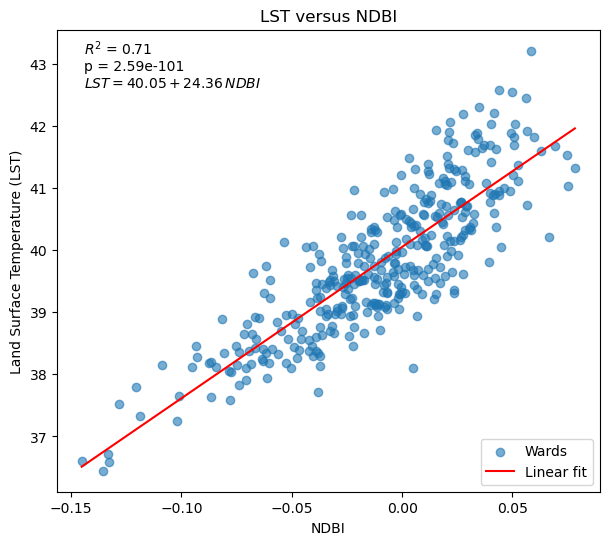

In [31]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("NDBI")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus NDBI")
plt.legend()

# annotation

plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST  = {intercept:.2f} + {slope:.2f}\\,NDBI$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [32]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['NDBI']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     908.6
Date:                Wed, 14 Jan 2026   Prob (F-statistic):          2.59e-101
Time:                        23:00:15   Log-Likelihood:                -347.65
No. Observations:                 369   AIC:                             699.3
Df Residuals:                     367   BIC:                             707.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         40.0501      0.033   1197.655      0.0

In [33]:
pearsonr(merged['NDBI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.8439684626358558), pvalue=np.float64(2.586718708862374e-101))

#### BSI

In [34]:
# x and y
x = merged["BSI"]
y = merged["mean_lst"]

In [35]:
# plot
# plt.figure(figsize=(7, 6))
# plt.scatter(x, y, alpha=0.6, label="Pixels")

In [36]:
fig_path = IMAGES_DIR / 'regression_bangalore_BSI_computed.png'

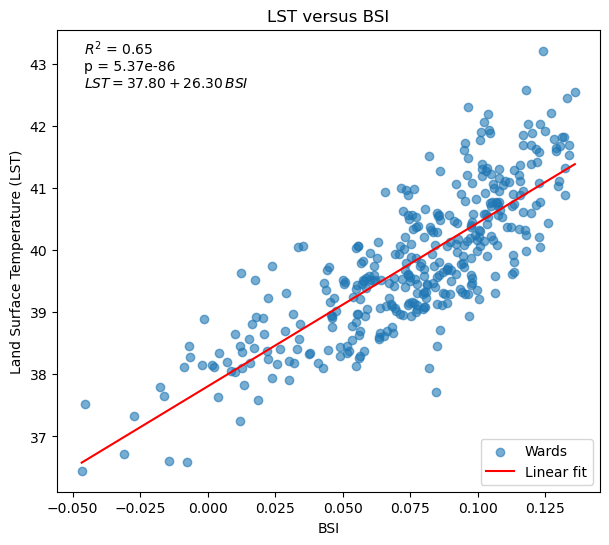

In [37]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("BSI")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus BSI")
plt.legend()


# annotation


plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST  = {intercept:.2f} + {slope:.2f}\\,BSI$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [38]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['BSI']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     685.8
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           5.37e-86
Time:                        23:00:35   Log-Likelihood:                -383.07
No. Observations:                 369   AIC:                             770.1
Df Residuals:                     367   BIC:                             778.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         37.8049      0.084    449.196      0.0

In [39]:
pearsonr(merged['BSI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.807090538846504), pvalue=np.float64(5.369669707628395e-86))